In [18]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import numpy as np
import re
from glob import glob
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from collections import defaultdict
pio.renderers.default = 'notebook'
%matplotlib widget

In [2]:
files = glob("results/*")

In [3]:
def read_pair_file(filename):
    pairs = {}
    with open(filename, 'r') as f:
        for line in f:
            match = re.match(r'#pair\s+"(.+?)"\s+"(.+?)"', line)
            if match:
                key, value = match.group(1), match.group(2)
                # Try to convert to numeric where possible
                try:
                    value = pd.to_numeric(value)
                except (ValueError, TypeError):
                    pass
                pairs[key] = value
    return pd.Series(pairs)

In [4]:
results = []
for filename in files:
    s = read_pair_file(filename)
    words = filename.split("/")[1].split("_")
    if len(words) < 5:
        continue
    s['algorithm'] = words[0]
    s['heuristic'] = words[1]
    s['weight'] = float(words[2])
    s['width'] = int(words[3])
    s['instance'] = int(words[4])
    if (s['algorithm'] in ["rrd", "ees"]) and (s['width'] != -1):
        continue
    results.append(s)

        

In [5]:
res1 = pd.DataFrame(results)

In [6]:
res1.loc[res1.weight == -1, "weight"] = 1

res1.loc[res1["total raw cpu time"].isna(),"total raw cpu time" ] = 300
res1.loc[res1['final sol cost'].isna(),'final sol cost' ] = res1['final sol cost'].max()



In [7]:
res1.columns



Index(['wall start date', 'wall start time', 'machine id', 'cost',
       'initial heuristic', 'initial distance', 'algorithm', 'final sol cost',
       'state size', 'packed state size', 'final sol length',
       'total raw cpu time', 'total wall time', 'total nodes expanded',
       'total nodes generated', 'total nodes duplicated',
       'total nodes reopened', 'closed list type', 'closed fill',
       'closed collisions', 'closed resizes', 'closed buckets',
       'closed max bucket fill', 'open list type', 'node size', 'weight',
       'h error last', 'd error last', 'wall finish time', 'wall finish date',
       'max virtual kilobytes', 'heuristic', 'width', 'instance',
       'Astar expansions', 'beam expansions'],
      dtype='object')

In [8]:
results = defaultdict(lambda: defaultdict(list))
for heur in set(res1.heuristic):
    res = res1.loc[res1.heuristic == heur]
    fig = go.Figure()
    for (width, algorithm), g1 in res.groupby(['width', 'algorithm']):
        if algorithm in ("wastar", "bsbs", "rrd"):
            xs = []
            ys = []
            for weight, group in g1.groupby('weight'):
                group = group.set_index('instance').sort_index()
                results[heur][weight].append(group['total raw cpu time'])


In [10]:
steve_res = pd.read_csv('./data.csv')
steve_res2 = pd.read_csv('./datatry2.csv')

In [25]:
steve_res_renamed2['res.alg_init_cpu_sec'].max(), steve_res_renamed2['res.cpu_sec'].min()

(np.float64(1.446e-05), np.float64(0.000597137))

In [21]:
steve2cols = {
    'alg.name':                 'algorithm',
    'alg.arguments.weight':     'weight',
    'alg.arguments.dup':        None,      # best guess
    'dom.name':                 None,                     # no clear match
    'dom.arguments.cost':       'cost',
    'res.halt_reason':          None,                     # no clear match
    'res.solution_length':      'final sol length',
    'res.solution_cost':        'final sol cost',
    'res.expansions':           'total nodes expanded',
    'res.generations':          'total nodes generated',
    'res.wall_sec':             'total wall time',
    'res.wall_matches_cpu':     None,                     # no clear match
    'res.exp_rate':             None,                     # no clear match
    'res.aux':                  None,                     # no clear match
}
steve_res_renamed = steve_res.rename(columns={k: v for k, v in steve2cols.items() if v is not None})
steve_res_renamed['algorithm'] = steve_res_renamed['algorithm'] + '_steve'
steve_res_renamed2 = steve_res2.rename(columns={k: v for k, v in steve2cols.items() if v is not None})
steve_res_renamed2['algorithm'] = steve_res_renamed2['algorithm'] + '_steve2'

steve_res_renamed2['total raw cpu time'] = steve_res_renamed2['res.cpu_sec'] - steve_res_renamed2['res.alg_init_cpu_sec']

In [13]:
# res1 = pd.concat([res1, steve_res_renamed], ignore_index=True)
set(res1.columns)

{'Astar expansions',
 'algorithm',
 'beam expansions',
 'closed buckets',
 'closed collisions',
 'closed fill',
 'closed list type',
 'closed max bucket fill',
 'closed resizes',
 'cost',
 'd error last',
 'final sol cost',
 'final sol length',
 'h error last',
 'heuristic',
 'initial distance',
 'initial heuristic',
 'instance',
 'machine id',
 'max virtual kilobytes',
 'node size',
 'open list type',
 'packed state size',
 'state size',
 'total nodes duplicated',
 'total nodes expanded',
 'total nodes generated',
 'total nodes reopened',
 'total raw cpu time',
 'total wall time',
 'wall finish date',
 'wall finish time',
 'wall start date',
 'wall start time',
 'weight',
 'width'}

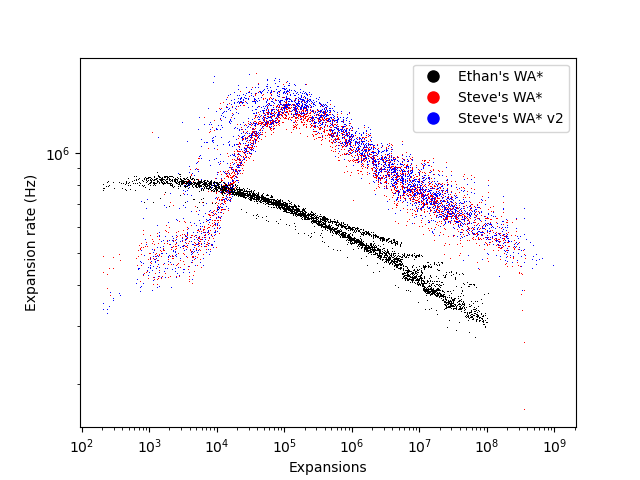

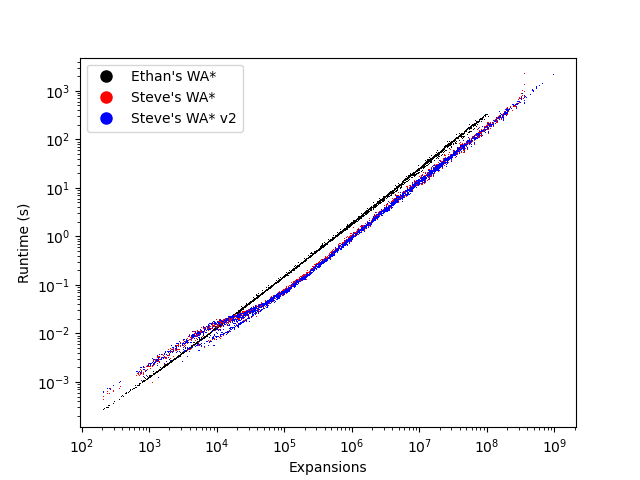

In [22]:
plt.figure()
r = res1.loc[res1.algorithm == "wastar-dropdups"]
plt.plot(r['total nodes expanded'], r['total nodes expanded']/r['total raw cpu time'], ",k", label = "Ethan's WA*")
plt.plot(steve_res_renamed['total nodes expanded'], steve_res_renamed['total nodes expanded']/steve_res_renamed['total wall time'], ",r", label = "Steve's WA*")
plt.plot(steve_res_renamed2['total nodes expanded'], steve_res_renamed2['total nodes expanded']/steve_res_renamed2['total raw cpu time'], ",b", label = "Steve's WA* v2")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("Expansion rate (Hz)")
plt.xlabel("Expansions")
plt.legend()
leg = plt.gca().legend()
for handle in leg.legend_handles:
    handle.set_marker('o')       # switch to visible marker in legend only
    handle.set_markersize(8)
plt.savefig("expansion-rate.png")

plt.figure()
r = res1.loc[res1.algorithm == "wastar-dropdups"]
plt.plot(r['total nodes expanded'], r['total raw cpu time'], ",k", label = "Ethan's WA*")
plt.plot(steve_res_renamed['total nodes expanded'], steve_res_renamed['total wall time'], ",r", label = "Steve's WA*")
plt.plot(steve_res_renamed2['total nodes expanded'], steve_res_renamed2['total raw cpu time'], ",b", label = "Steve's WA* v2")

plt.yscale("log")
plt.xscale("log")
plt.ylabel("Runtime (s)")
plt.xlabel("Expansions")
plt.legend()
leg = plt.gca().legend()
for handle in leg.legend_handles:
    handle.set_marker('o')       # switch to visible marker in legend only
    handle.set_markersize(8)
plt.savefig("runtime.png")

In [ ]:
numpy.

In [28]:
for heur in set(res1.heuristic):
    res = res1.loc[res1.heuristic == heur]
    fig = go.Figure()
    for (width, algorithm), g1 in res.groupby(['width', 'algorithm']):
        # if not "bsbs" == algorithm:
        #     continue
        xs = []
        ys = []
        for weight, group in g1.groupby('weight'):
            group = group.set_index('instance').sort_index()
            if weight in results[heur]:
                group = group.loc[(pd.DataFrame(results[heur][weight]) < 300).all(axis = 0)]
            xs.append(weight)
            ys.append(group['total nodes expanded'].sum())
        
        xs, ys = zip(*sorted(zip(xs, ys)))
        fig.add_trace(go.Scatter(
            x=list(xs),
            y=list(ys),
            mode='lines+markers',
            name=f"{algorithm} width={width}",
        ))
    fig.update_layout(
        title='Korf 100 - ' + heur,
        xaxis_title='Weight',
        yaxis_title='total num exp',
            yaxis_type='log',
        xaxis_type='log',
        yaxis=dict(tickformat='~g'),
        xaxis=dict(tickformat='~g'),
    )
            
    fig.show()
    plotly.offline.plot(fig, filename=heur + '-expansions.html')

TypeError: can only concatenate str (not "float") to str

In [10]:
weight, heur, results[heur][weight]

(3.0,
 'inverse',
 [instance
  1      0.011042
  2      0.010652
  3      0.117428
  4      0.076071
  5      0.004666
           ...   
  96     0.006394
  97     0.013785
  98     0.219602
  99     0.015602
  100    0.020352
  Name: total raw cpu time, Length: 100, dtype: float64,
  instance
  1       54.007279
  2       53.064835
  3       98.294369
  4       50.940278
  5        0.000375
            ...    
  96     138.905649
  97      39.640170
  98      22.668728
  99      16.407237
  100      8.071834
  Name: total raw cpu time, Length: 100, dtype: float64,
  instance
  1      0.003983
  2      0.007469
  3      0.003372
  4      0.014238
  5      0.001424
           ...   
  96     0.009248
  97     0.010914
  98     0.003054
  99     0.013293
  100    0.002736
  Name: total raw cpu time, Length: 100, dtype: float64,
  instance
  1      0.010251
  2      0.007252
  3      0.006443
  4      0.008217
  5      0.015443
           ...   
  96     0.005785
  97     0.017117
  98   

In [11]:
for heur in set(res1.heuristic):
    res = res1.loc[res1.heuristic == heur]
    fig = go.Figure()
    for (width, algorithm), g1 in res.groupby(['width', 'algorithm']):
        # if (algorithm not in ["rrdnofocal", "bsbs", "wastar", "ees"]):
        #     continue
        xs = []
        ys = []
        for weight, group in g1.groupby('weight'):
            group = group.set_index('instance').sort_index()
            if weight in results[heur]:
                group = group.loc[(pd.DataFrame(results[heur][weight]) < 300).all(axis = 0)]
            xs.append(weight)
            ys.append(group['total raw cpu time'].sum())
        
        xs, ys = zip(*sorted(zip(xs, ys)))
        fig.add_trace(go.Scatter(
            x=list(xs),
            y=list(ys),
            mode='lines+markers',
            name=f"{algorithm} width={width}",
        ))
    print('Korf 100 - ' + heur)
    fig.update_layout(
        # title='Korf 100 - ' + heur,
        xaxis_title='Weight',
        yaxis_title='total CPU time (s)',
            yaxis_type='log',
        xaxis_type='log',
        yaxis=dict(tickformat='~g'),
        xaxis=dict(tickformat='~g'),
    )
    fig.update_layout(width=600, height=400) 
    fig.update_xaxes(range=[0, .5])
    fig.show()
    plotly.offline.plot(fig, filename=heur + '-runtime.html')

Korf 100 - heavy


Korf 100 - unit


Korf 100 - inverse


In [12]:
for heur in set(res1.heuristic):
    res = res1.loc[res1.heuristic == heur]
    fig = go.Figure()
    for (width, algorithm), g1 in res.groupby(['width', 'algorithm']):
        xs = []
        ys = []
        for weight, group in g1.groupby('weight'):
            group = group.set_index('instance').sort_index()
            if weight in results[heur]:
                group = group.loc[(pd.DataFrame(results[heur][weight]) < 300).all(axis = 0)]
            xs.append(weight)
            ys.append((group['total raw cpu time'] < 300.0).sum())
        
        xs, ys = zip(*sorted(zip(xs, ys)))
        fig.add_trace(go.Scatter(
            x=list(xs),
            y=list(ys),
            mode='lines+markers',
            name=f"{algorithm} width={width}",
        ))
    fig.update_layout(
        title='Korf 100 - ' + heur,
        xaxis_title='Weight',
        yaxis_title='Percent Solved',
            yaxis_type='log',
        xaxis_type='log',
        yaxis=dict(tickformat='~g'),
        xaxis=dict(tickformat='~g'),
    )
            
    fig.show()
    plotly.offline.plot(fig, filename=heur + '-percsolved.html')

In [13]:
for heur in set(res1.heuristic):
    res = res1.loc[res1.heuristic == heur]
    fig = go.Figure()
    for (width, algorithm), g1 in res.groupby(['width', 'algorithm']):
        xs = []
        ys = []
        for weight, group in g1.groupby('weight'):
            group = group.set_index('instance').sort_index()
            if weight in results[heur]:
                group = group.loc[(pd.DataFrame(results[heur][weight]) < 300).all(axis = 0)] 
            xs.append(weight)
            ys.append(group['final sol cost'].sum())
        
        xs, ys = zip(*sorted(zip(xs, ys)))
        fig.add_trace(go.Scatter(
            x=list(xs),
            y=list(ys),
            mode='lines+markers',
            name=f"{algorithm} width={width}",
        ))
    fig.update_layout(
        title='Korf 100 - ' + heur,
        xaxis_title='Weight',
        yaxis_title='Total Cost *With penalized timeout*',
            yaxis_type='log',
        xaxis_type='log',
        yaxis=dict(tickformat='~g'),
        xaxis=dict(tickformat='~g'),
    )
            
    fig.show()
    plotly.offline.plot(fig, filename=heur + '-total-cost.html')

In [14]:
plotly.offline.plot(fig, filename='results.html')

'results.html'

In [15]:
res1['final sol cost'].isna().any()

np.False_